# Student Details

Student Name: **Nofri Alhadi**

Student ID: **23188901**

# Activity 6: Pytorch and CNNs for Fashion-MNIST

In this activity, we are going to explore designing various neural networks for the FashionMNIST classification problem. This is, of course, a 'toy' problem, but the fundamentals of classification of images is here.


## Hints, tips, and notes

* Here I'm not going to mandate TensorBoard. In Colab, this is a little bit more involved. Instead, we'll just put the losses and accuracies in a list and print them after training. However, TensorBoard is very useful, particularly for projects, so I suggest playing around with it.
* Some of these runs will take several minutes to complete. This is the nature of ML. Grab a beer, or a coffee.

As usual, we will give you some code that you use to build the rest of the activity.

# Common Code

All the imports

In [2]:
!pip install torch-summary
!pip install torchvision

import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
#from torchvision import datasets
from torchvision import models
from torchvision.transforms import ToTensor, Normalize, transforms, Resize
from torchsummary import summary
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate


  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/32/81/f81f5c6ecb0ef29affb69d2e615e20b531420ba866dd7cd504f9dc766d8c/torchvision-0.17.0-cp311-cp311-macosx_10_13_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.8 MB/s eta 0:00:0000:0100:01


In [3]:
# Suppressing Warnings:
import warnings
warnings.filterwarnings("ignore")

### 1. Select the device to use.

To access the GPU on Google Colab, `Select Runtime` -> `Change Runtime Type` and pick `GPU` from the `Hardware Accelerator` dropdown menu. In the free version, the GPU is modest. If you buy credits, you get access to a much nice A100 GPU. In both cases, you may find contention for the resource is an issue, but less likely to happen if you use credits.

In [4]:
# Get appropriate device for training
device = torch.device( "cuda"     # CUDA is a programming interface for certain Nvidia GPUs
           if torch.cuda.is_available()
           else "mps"  # Kind of like CUDA for a mac, I guess? I don't use macs
           if torch.backends.mps.is_available()
           else "cpu" )   # If you end up with CPU, go use Google Colab and get a GPU

print(f"{device} device available")

mps device available


### 2. Code for training the models

I'm going to provide this code, rather than you having to struggle creating it. This is a normal training cycle with PyTorch. However, I do want you to explain the PyTorch functions called in the train function. I will marke them with comments.

In [5]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()        #<--- what is this function for?

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)   #<--- this is a bit funny, explain it

        # Compute prediction error
        pred = model(X)                     #<--- what is this for?
        loss = loss_fn(pred, y)             #<--- what is this for?

        # This is the backprop set up. Explain what each of the steps do
        loss.backward()                     #<--- what is this for?
        optimizer.step()                    #<--- what is this for?
        optimizer.zero_grad()               #<--- what is this for?

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    loss, accuracy = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss += loss_fn(pred, y).item()
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()
    loss /= num_batches
    accuracy /= size

    return loss, accuracy

def train_loop(train_dataloader, test_dataloader, model, loss_fn, optimizer, epochs):
    train_loss = []
    train_accuracy = []
    test_loss = []
    test_accuracy = []

    # Iterate over each epoch
    for t in range(epochs):
        print(f"Epoch {t+1}:\n")
        train(train_dataloader, model, loss_fn, optimizer)

        # Get the overall loss and accuracy for both train and test datasets
        tr_loss, tr_acc = test(train_dataloader, model, loss_fn)
        ts_loss, ts_acc = test(test_dataloader, model, loss_fn)

        print(f"\nTrain Error: \n Accuracy: {(100*tr_acc):>0.1f}%, Avg loss: {tr_loss:>8f} \n")
        print(f"Test Error: \n Accuracy: {(100*ts_acc):>0.1f}%, Avg loss: {ts_loss:>8f} \n")

        # Store and return the losses and accuracies. We can graph these later
        train_loss = train_loss + [tr_loss]
        train_accuracy = train_accuracy + [tr_acc]
        test_loss = test_loss + [ts_loss]
        test_accuracy = test_accuracy + [ts_acc]

    print("Done training!")
    return train_loss, train_accuracy, test_loss, test_accuracy



### <font color='red'>Your input here.</font>
<font color='red'>Enter you description of the above parts:</font>



```
model.train()
is used during training to enable layers like dropout.
```

```
X, y = X.to(device), y.to(device)
This moves the input data (X and y) to the specified device like GPU for faster computation if available.
```


```
pred = model(X)
This calculates the predicted outputs of the model for the given input.
```


```
loss = loss_fn(pred, y)
This computes the loss between the predicted outputs and the actual labels.
```


```
loss.backward()  
This computes the gradients of the loss with respect to the model parameters, facilitating parameter updates during optimization.
```


```
optimizer.step()
This updates the model parameters using the computed gradients.
```


```
optimizer.zero_grad()
This zeroes the gradients for the next iteration to avoid accumulating gradients from multiple batches.  
```


### 3. Load the data

1. Load the Fashion-MNIST dataset using `torchvision`'s `datasets` library (e.g., [`datasets.FashionMNIST...`](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)...)
2. When loading the data, convert it to tensor format ([`transforms.ToTensor`](https://pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html)), and apply the standard scaler to the data (using [`transforms.Normalize`](https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html)). Use the [`transforms.Resize`](https://pytorch.org/vision/main/generated/torchvision.transforms.Resize.html) transform to turn it into a 28x28 image rather than a 784-vector
    * Rather than loading the data, and caluclating the mean and std, you can use the values `mean = 0.2859` and `std = 0.3530`. I pre-calculated these for you!
3. Create the [`DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)s. Here we're going to use a batch size of 64.
4. Display a few examples of the dataset - this is always a good idea to make sure the data has loaded correctly

We haven't really touched on batch size yet, because up to now we have used plain old gradient descent. Later on, we will use the Adam optimiser, because it is quicker and uses less memory. But Adam is a mini-batch optimizer, and you have to pick that mini-batch size. Bit more info on this, if you are interested:
 * https://sebastianraschka.com/faq/docs/gradient-optimization.html
 * https://machinelearningmastery.com/adam-optimization-algorithm-for-deep-learning/

We need to set the batch size when we create the dataloaders.

### <font color='red'>Your code here.</font>
<font color='red'>Enter your code in the cell(s) below:</font>

In [6]:
# define transform format for convert to tensor format and apply standard scaler to the data
transform = transforms.Compose([Resize((28,28)), # transform to 28x28 image rather than a 784-vector
                                ToTensor(),
                                Normalize(mean=0.2859, std=0.3530)])

# Load the Fashion-MNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Create the DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)


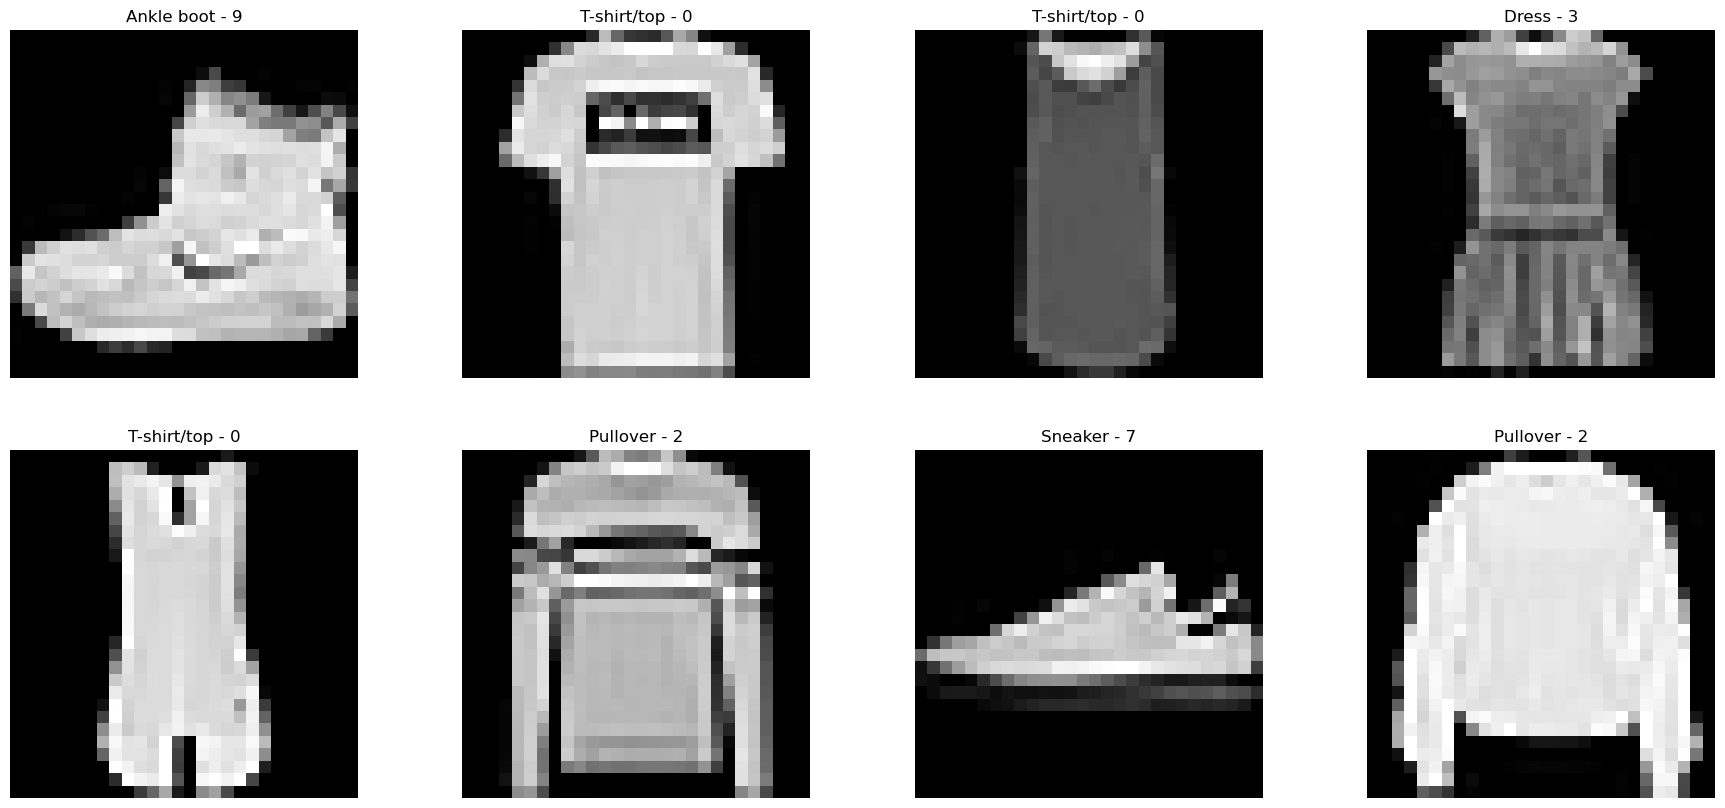

In [7]:
# Display a few examples of the dataset

#text_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_labels = ["T-shirt/top - 0", "Trouser - 1", "Pullover - 2", "Dress - 3", "Coat - 4", "Sandal - 5", "Shirt - 6", "Sneaker - 7", "Bag - 8", "Ankle boot - 9"]

dataiter = iter(train_dataloader)
images, labels = next(dataiter)

# Visualize the image
fig, ax = plt.subplots(2, 4, figsize=(22, 10))
fig.subplots_adjust(wspace=0.3)
ax = ax.flatten()

for i in range(8):
    img = images[i][0].numpy().squeeze()
    label = class_labels[labels[i].item()]
    ax[i].imshow(img, cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(label)

plt.show()



---
## 1. Replicate the Neural Network from the previous tasks for the FashionMNIST dataset
---


In the previous activity, you designed a fully connected neural network (a multi-layer perceptron) to predict on Fashion-MNIST.

1. Replicate the best network that you found in that activity, but in PyTorch.
1. Use [`summary`](https://pypi.org/project/torch-summary/) to display a summary of your model.
1. Use some random inputs to test the model. This will be meaningless, as the model is not trained yet (and the inputs are random). However, it is useful to test that you have defined the model at leats without any coding errors.

Hints and notes:
 * We need to [`Flatten`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html) the incoming data. In the previous step, you loaded the dataset as a 28x28 image (because, later on we will be using CNNs that require image inputs). However, fully connected layers require vector inputs. `nn.Flatten` converts the image input to a vector (i.e., a 28x28 image to a 784 vector).
 * Use [`.to(device)`](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html) to "send" objects to the GPU (if you have one). E.g., once you define your class for the neural network, you will create an instance of that NN - you need to send this object to the GPU.
 * Generally, at inference time, we will use a [`softmax`](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html) on the output of the model. Prior to the softmax, the model outputs a score per class. That is, there will be 10 outputs. However, here we will ignore the softmax part.


### <font color='red'>Your code here.</font>
<font color='red'>Enter your code in the cell(s) below:</font>

In [14]:
# Define parameters
LEARNING_RATE = 0.001  #1e-3
N_EPOCH = 20

# define number of epoch
epochs = list(range(1, N_EPOCH + 1))

In [15]:
# Define Neural Network model
class NeuralNetwork(nn.Module):               # 3 hidden layers (100 - 100 - 50)
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 100)    # input(28*28) + 1st hidden layer(100)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(100, 100)        # 1st hidden layer(100) + 2nd hidden layer(100)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(100, 50)         # 2st hidden layer(100) + 3rd hidden layer(50)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(50, 10)          # 3rd hidden layer(50) + output(10)

    def forward(self, x):
        #print(x.size())
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x


In [21]:
# define model instance
model_nn = NeuralNetwork()

# "send" objects to the GPU
model_nn.to(device)

# show model summary
summary(model_nn, (1,28*28))   #summary(model_nn, (1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
├─Flatten: 1-1                           [-1, 784]                 --
├─Linear: 1-2                            [-1, 100]                 78,500
├─ReLU: 1-3                              [-1, 100]                 --
├─Linear: 1-4                            [-1, 100]                 10,100
├─ReLU: 1-5                              [-1, 100]                 --
├─Linear: 1-6                            [-1, 50]                  5,050
├─ReLU: 1-7                              [-1, 50]                  --
├─Linear: 1-8                            [-1, 10]                  510
Total params: 94,160
Trainable params: 94,160
Non-trainable params: 0
Total mult-adds (M): 0.09
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.36
Estimated Total Size (MB): 0.36


Layer (type:depth-idx)                   Output Shape              Param #
├─Flatten: 1-1                           [-1, 784]                 --
├─Linear: 1-2                            [-1, 100]                 78,500
├─ReLU: 1-3                              [-1, 100]                 --
├─Linear: 1-4                            [-1, 100]                 10,100
├─ReLU: 1-5                              [-1, 100]                 --
├─Linear: 1-6                            [-1, 50]                  5,050
├─ReLU: 1-7                              [-1, 50]                  --
├─Linear: 1-8                            [-1, 10]                  510
Total params: 94,160
Trainable params: 94,160
Non-trainable params: 0
Total mult-adds (M): 0.09
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.36
Estimated Total Size (MB): 0.36

Now train the model.

We will use [Cross Entropy Loss](https://towardsdatascience.com/cross-entropy-loss-function-f38c4ec8643e), and as discussed, the Adam optimiser (with learning rate = 0.001).

* Call the training loop - I would suggest a max of ~20 epochs
* Use matplotlib to plot the train and test loss, and the train and test accuracy
* Describe what you see in the graphs

This training could take a few minutes. But note how you will see a bunch of losses reported in each epoch? These are the mini-batches in Adam that we discussed before. Then there will be an overall Train and Test error reported for the Epoch.

### <font color='red'>Your code here.</font>
<font color='red'>Enter your code in the cell(s) below:</font>

In [22]:
# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=LEARNING_RATE)   # Note, replace model with the instance name of your model

# train the model
train_loss_nn, train_accuracy_nn, test_loss_nn, test_accuracy_nn = train_loop(
    train_dataloader, test_dataloader, model_nn, loss_fn, optimizer, epochs=N_EPOCH)


Epoch 1:



RuntimeError: Placeholder storage has not been allocated on MPS device!

In [ ]:
# print the loss in table format
print('\nNeural Network Model - Loss:')
loss_train_test = np.hstack((np.vstack(epochs), np.vstack(train_loss_nn), np.vstack(test_loss_nn)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(loss_train_test, headers, tablefmt="pretty", showindex=False))

# print the accuracy in table format
print('\nNeural Network Model - Accuracy:')
accuracy_train_test = np.hstack((np.vstack(epochs), np.vstack(train_accuracy_nn), np.vstack(test_accuracy_nn)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(accuracy_train_test, headers, tablefmt="pretty", showindex=False))


Neural Network Model - Loss:
+--------+---------------------+---------------------+
| Epochs |        Train        |        Test         |
+--------+---------------------+---------------------+
|  1.0   | 0.3934065194399372  | 0.43771234610278137 |
|  2.0   | 0.33651302583309123 | 0.3926637937213964  |
|  3.0   | 0.30941753025089247 | 0.37512746633617744 |
|  4.0   | 0.29310748992221697 | 0.37154712879164203 |
|  5.0   | 0.2753162017739467  |  0.366692984797013  |
|  6.0   | 0.2628143871151435  | 0.3606349398755723  |
|  7.0   | 0.2613788447948471  | 0.37007692997242997 |
|  8.0   | 0.2528610025673533  | 0.3750691409608361  |
|  9.0   | 0.24755580220689208 | 0.37478822920542615 |
|  10.0  | 0.23819781040379615 | 0.3775357644364333  |
|  11.0  | 0.23745356553367206 | 0.39100457552322154 |
|  12.0  | 0.23980129320722526 | 0.40791279604290703 |
|  13.0  | 0.2299993533982651  | 0.4061347012212322  |
|  14.0  | 0.2304608964406923  | 0.4205901478980757  |
|  15.0  |  0.222971652858833  | 0.

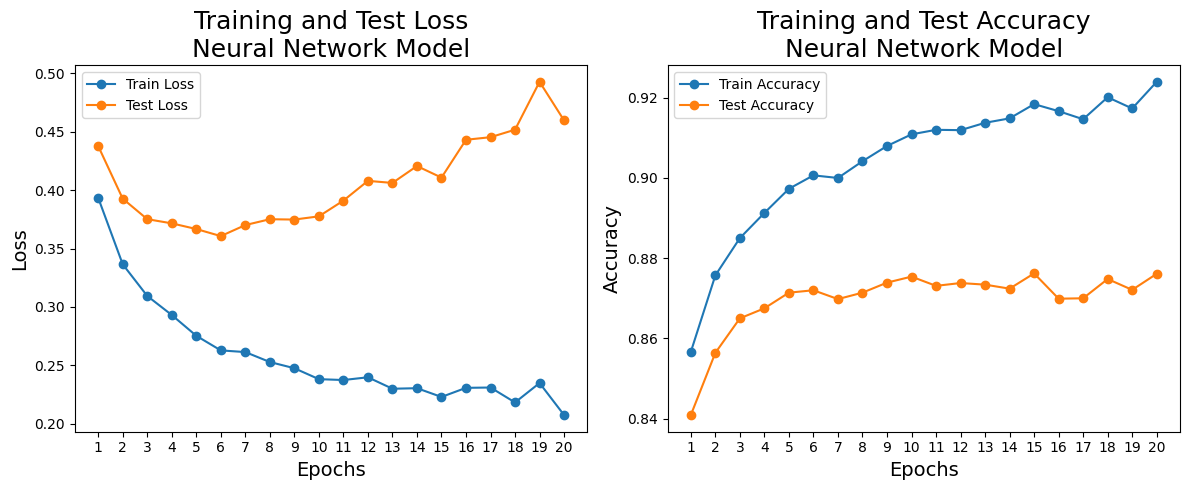

In [ ]:
# Use matplotlib to plot the train and test loss, and the train and test accuracy

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_nn, label='Train Loss', marker='o')
plt.plot(epochs, test_loss_nn, label='Test Loss', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Loss\nNeural Network Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_nn, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracy_nn, label='Test Accuracy', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Accuracy\nNeural Network Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

## Training and Test Loss
Epochs 1-5, Both the training and test loss decrease, indicating that the model is learning and generalizing well. The training loss is consistently lower than the test loss, suggesting that the model is not overfitting.


Epochs 6-15, Both losses are decreasing, albeit at a slower pace, with the training and test losses remaining close, indicating good generalisation.


Epochs 16-20, It seems that the loss during the training phase is decreasing, but at the same time, the loss during the testing phase is increasing. This divergence indicates that the model could be overfitting the training data, which means that it's fitting too closely to the specifics of the training data and not generalizing to new data. If this is not addressed, the model's performance on unseen data will degrade. To prevent overfitting, it might be reasonable to monitor the training progress closely and stop it around Epoch 15.


## Training and Test Accuracy
Epochs 1-5, Both training and testing accuracy show a steady increase, indicating effective learning of the model. Test accuracy trails slightly behind training accuracy, which is a normal occurrence.


Epochs 6-15, The accuracies of the model are increasing, but at a slower rate. The training accuracy remains consistently high, which indicates that the model is fitting the training data well. The test accuracy also improves, but it may start to plateau, suggesting a good balance between learning and generalization.


Epochs 16-20, It is important to monitor the accuracy of a model during training. Sometimes, the training accuracy may keep increasing while the test accuracy may show signs of plateauing or even decreasing. This means that the model is becoming too specialized in the training data, a phenomenon known as overfitting. To prevent overfitting, it may be necessary to monitor the loss plot and stop the training around Epoch 15. It is also important to keep an eye on the gap between the training and test accuracy, as it could be an indicator of overfitting.



---

# 2. Replicate LeNet-5 for Fashion-MNIST

---


Below is the LeNet architecture (from https://en.wikipedia.org/wiki/LeNet). If you search on the internet, you will find slightly different implementations and descriptions of LeNet-5, but below is what was actually in LeCun's [original paper](https://ieeexplore.ieee.org/document/726791). Of course, LeCun was applying this to the digit recognition problem (MNIST), but we are looking at Fashion-MNIST.

 * Create the model in PyTorch.
 * Train the model using the same parameters as above, and plot the loss and accuracy.
 * Discuss and compare (in a markdown cell) with the fully connected model above. Particularly consider - number of parameters, performance, and overfitting?

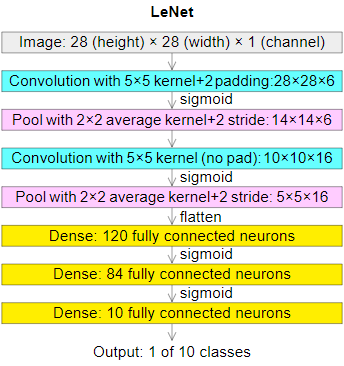

### <font color='red'>Your code here.</font>
<font color='red'>Enter your code in the cell(s) below:</font>

In [ ]:
# Define LeNet architecture model
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        # Fully connected layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Convolutional layers with ReLU activation and max pooling
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        x = nn.functional.relu(self.conv2(x))
        x = nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        # Flatten the output for the fully connected layers
        #print(x.size())
        x = x.view(-1, 16 * 5 * 5)
        # Fully connected layers with ReLU activation
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        # Output layer
        x = self.fc3(x)
        return x

In [ ]:
# define model instance
model_LeNet = LeNet()

# "send" objects to the GPU
model_LeNet.to(device)

# show model summary
summary(model_LeNet, (1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 6, 28, 28]           156
├─Conv2d: 1-2                            [-1, 16, 10, 10]          2,416
├─Linear: 1-3                            [-1, 120]                 48,120
├─Linear: 1-4                            [-1, 84]                  10,164
├─Linear: 1-5                            [-1, 10]                  850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
Total mult-adds (M): 0.42
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.24
Estimated Total Size (MB): 0.29


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 6, 28, 28]           156
├─Conv2d: 1-2                            [-1, 16, 10, 10]          2,416
├─Linear: 1-3                            [-1, 120]                 48,120
├─Linear: 1-4                            [-1, 84]                  10,164
├─Linear: 1-5                            [-1, 10]                  850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
Total mult-adds (M): 0.42
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.24
Estimated Total Size (MB): 0.29

In [ ]:
# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_LeNet.parameters(), lr=LEARNING_RATE)   # Note, replace model with the instance name of your model

# train the model
train_loss_lenet, train_accuracy_lenet, test_loss_lenet, test_accuracy_lenet = train_loop(
    train_dataloader, test_dataloader, model_LeNet, loss_fn, optimizer, epochs=N_EPOCH)

Epoch 1:

loss: 2.297749  [   64/60000]
loss: 0.805809  [ 6464/60000]
loss: 0.491488  [12864/60000]
loss: 0.591209  [19264/60000]
loss: 0.493217  [25664/60000]
loss: 0.481840  [32064/60000]
loss: 0.412014  [38464/60000]
loss: 0.594692  [44864/60000]
loss: 0.536240  [51264/60000]
loss: 0.422757  [57664/60000]

Train Error: 
 Accuracy: 84.3%, Avg loss: 0.415141 

Test Error: 
 Accuracy: 83.5%, Avg loss: 0.441015 

Epoch 2:

loss: 0.346290  [   64/60000]
loss: 0.394218  [ 6464/60000]
loss: 0.283035  [12864/60000]
loss: 0.443591  [19264/60000]
loss: 0.422685  [25664/60000]
loss: 0.410126  [32064/60000]
loss: 0.300889  [38464/60000]
loss: 0.544514  [44864/60000]
loss: 0.435029  [51264/60000]
loss: 0.379050  [57664/60000]

Train Error: 
 Accuracy: 87.4%, Avg loss: 0.338831 

Test Error: 
 Accuracy: 86.5%, Avg loss: 0.371003 

Epoch 3:

loss: 0.247939  [   64/60000]
loss: 0.285722  [ 6464/60000]
loss: 0.255606  [12864/60000]
loss: 0.390571  [19264/60000]
loss: 0.402250  [25664/60000]
loss: 0.

In [ ]:
# print the loss in table format
print('\nLeNet Model - Loss:')
loss_train_test = np.hstack((np.vstack(epochs), np.vstack(train_loss_lenet), np.vstack(test_loss_lenet)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(loss_train_test, headers, tablefmt="pretty", showindex=False))

# print the accuracy in table format
print('\nLeNet Model - Accuracy:')
accuracy_train_test = np.hstack((np.vstack(epochs), np.vstack(train_accuracy_lenet), np.vstack(test_accuracy_lenet)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(accuracy_train_test, headers, tablefmt="pretty", showindex=False))


LeNet Model - Loss:
+--------+---------------------+---------------------+
| Epochs |        Train        |        Test         |
+--------+---------------------+---------------------+
|  1.0   | 0.4151414908579926  | 0.44101474135165003 |
|  2.0   | 0.3388314134101751  | 0.3710033633526723  |
|  3.0   |  0.308161262565775  |  0.349698289374637  |
|  4.0   | 0.2927818751570258  | 0.3442189402071534  |
|  5.0   | 0.28221093760783483 | 0.3392923683117909  |
|  6.0   | 0.26928712412524325 | 0.33457648099228077 |
|  7.0   | 0.2518830948801183  | 0.3263562775816128  |
|  8.0   | 0.2530561774166853  | 0.3379059397870568  |
|  9.0   | 0.24648952221613069 | 0.35134129729240565 |
|  10.0  | 0.23975394607019196 | 0.3639692438256209  |
|  11.0  | 0.21773235501447466 | 0.3650481013735388  |
|  12.0  | 0.20206524934103368 | 0.3687275241419768  |
|  13.0  | 0.18767085277846754 |  0.375762501055268  |
|  14.0  | 0.18282970214592242 | 0.38809961545619237 |
|  15.0  | 0.18677943884365278 | 0.424660263

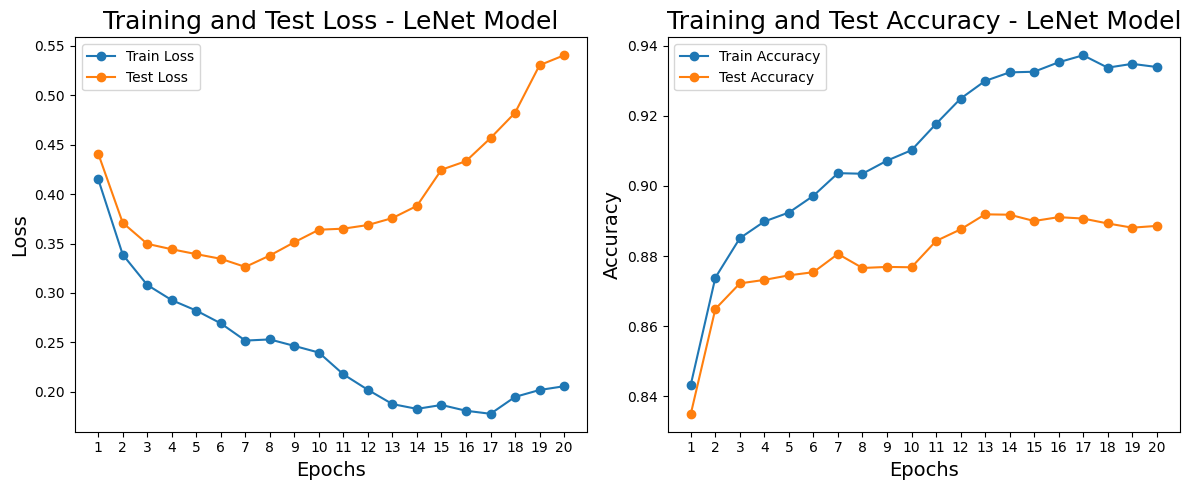

In [ ]:
# Use matplotlib to plot the train and test loss, and the train and test accuracy

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_lenet, label='Train Loss', marker='o')
plt.plot(epochs, test_loss_lenet, label='Test Loss', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Loss - LeNet Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_lenet, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracy_lenet, label='Test Accuracy', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Accuracy - LeNet Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

### <font color='red'>Your text here.</font>
<font color='red'>Enter your text descriptions in the cell below:</font>

## Training and Test Loss
Training Loss:

The initial value is relatively high at 0.43 but it decreases with each epoch. This indicates that the model is learning effectively from the training data. Although some fluctuations are observed, it shows a consistent downward trend. This may be because of the variations in the training data or the model adapting to different patterns.


Test Loss:

The test loss initially decreases from 0.45, which indicates that the model is performing well on the unseen data. This trend follows the training loss, which suggests that the model is generalizing well. However, around epoch 16, the test loss starts to increase, which could be a sign of overfitting. This means that the model might be fitting the training data too closely, resulting in reduced performance on the test set.


Comparison:

During the training phase, the loss value consistently decreases with each epoch, which suggests that the learning process is effective. However, during the testing phase, the loss value initially decreases but then starts to rise, indicating a point where the model's performance on the test set begins to degrade. After epoch 16, the difference between the training and test loss values increases, which indicates that the model may be overfitting.


## Training and Test Accuracy

Training Accuracy:

Starting at around 0.84, the value steadily increases with each epoch until it reaches approximately 0.94 by the 20th epoch. The consistent upward trend indicates that the model is effectively learning from the training data.


Test Accuracy:

The model's performance on the test set starts at 0.84 and increases initially, reaching a peak of 0.90 around the 9th epoch. It experiences some fluctuations but remains relatively stable in the range of 0.89 to 0.90. However, it shows signs of reaching a plateau after the initial increase, indicating that the model's performance on the test set has stabilized.

Comparison:

The accuracy during the training process keeps improving with each epoch, which indicates that the model is effectively learning and adapting to the training data. On the other hand, during the testing phase, the accuracy initially increases but eventually levels off around the 9th epoch. This indicates that the model's ability to generalize to new, unseen data stabilizes after this point.

### Plotting Neural Network Model and LeNet Model

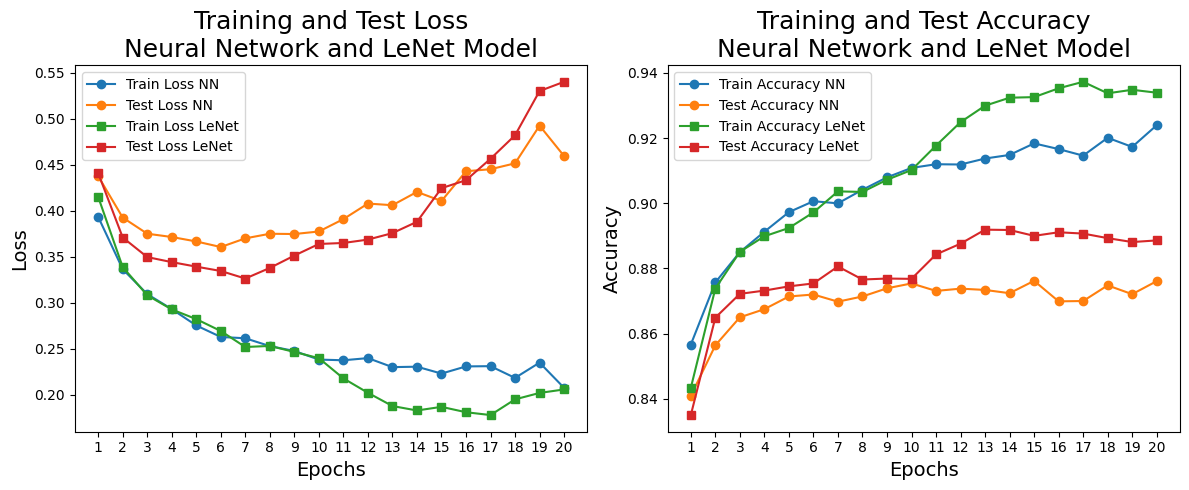

In [ ]:
# Plotting the loss Neural Network Model and LeNet Model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_nn, label='Train Loss NN', marker='o')
plt.plot(epochs, test_loss_nn, label='Test Loss NN', marker='o')
plt.plot(epochs, train_loss_lenet, label='Train Loss LeNet', marker='s')
plt.plot(epochs, test_loss_lenet, label='Test Loss LeNet', marker='s')
plt.xticks(epochs)
plt.title('Training and Test Loss\nNeural Network and LeNet Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy Neural Network Model and LeNet Model
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_nn, label='Train Accuracy NN', marker='o')
plt.plot(epochs, test_accuracy_nn, label='Test Accuracy NN', marker='o')
plt.plot(epochs, train_accuracy_lenet, label='Train Accuracy LeNet', marker='s')
plt.plot(epochs, test_accuracy_lenet, label='Test Accuracy LeNet', marker='s')
plt.xticks(epochs)
plt.title('Training and Test Accuracy\nNeural Network and LeNet Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

---
# 3. Modernise LeNet
---


Modernise LeNet. What are the preferred activation and pooling functions for modern CNNs?

* Update LeNet with these newer functions.
* Train using the same parameters as above.
* Compare and discuss with the above using the normal discussion criteria


### <font color='red'>Your code here.</font>
<font color='red'>Enter your code in the cell(s) below:</font>

In [ ]:
# Define Modernise LeNet architecture model
class ModernLeNet(nn.Module):
    def __init__(self):
        super(ModernLeNet, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        # Max pooling layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = nn.functional.relu(self.conv1(x))
        x = self.pool(x)
        x = nn.functional.relu(self.conv2(x))
        x = self.pool(x)
        # Flatten the output for the fully connected layers
        #print(x.size())
        x = x.view(-1, 64 * 7 * 7)
        # Fully connected layers with ReLU activation
        x = nn.functional.relu(self.fc1(x))
        # Output layer
        x = self.fc2(x)
        return x

In [ ]:
# define model instance
model_LeNet_modern = ModernLeNet()

# "send" objects to the GPU
model_LeNet_modern.to(device)

# show model summary
summary(model_LeNet_modern, (1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 28, 28]          320
├─MaxPool2d: 1-2                         [-1, 32, 14, 14]          --
├─Conv2d: 1-3                            [-1, 64, 14, 14]          18,496
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Linear: 1-5                            [-1, 128]                 401,536
├─Linear: 1-6                            [-1, 10]                  1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
Total mult-adds (M): 4.24
Input size (MB): 0.00
Forward/backward pass size (MB): 0.29
Params size (MB): 1.61
Estimated Total Size (MB): 1.90


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 28, 28]          320
├─MaxPool2d: 1-2                         [-1, 32, 14, 14]          --
├─Conv2d: 1-3                            [-1, 64, 14, 14]          18,496
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Linear: 1-5                            [-1, 128]                 401,536
├─Linear: 1-6                            [-1, 10]                  1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
Total mult-adds (M): 4.24
Input size (MB): 0.00
Forward/backward pass size (MB): 0.29
Params size (MB): 1.61
Estimated Total Size (MB): 1.90

In [ ]:
# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_LeNet_modern.parameters(), lr=LEARNING_RATE)   # Note, replace model with the instance name of your model

# train the model
train_loss_lenet_modern, train_accuracy_lenet_modern, test_loss_lenet_modern, test_accuracy_lenet_modern = train_loop(
    train_dataloader, test_dataloader, model_LeNet_modern, loss_fn, optimizer, epochs=N_EPOCH)

Epoch 1:

loss: 2.320080  [   64/60000]
loss: 0.537760  [ 6464/60000]
loss: 0.277600  [12864/60000]
loss: 0.434097  [19264/60000]
loss: 0.470011  [25664/60000]
loss: 0.476335  [32064/60000]
loss: 0.283293  [38464/60000]
loss: 0.539221  [44864/60000]
loss: 0.378173  [51264/60000]
loss: 0.353054  [57664/60000]

Train Error: 
 Accuracy: 88.4%, Avg loss: 0.316826 

Test Error: 
 Accuracy: 87.4%, Avg loss: 0.348651 

Epoch 2:

loss: 0.260626  [   64/60000]
loss: 0.282722  [ 6464/60000]
loss: 0.214809  [12864/60000]
loss: 0.305973  [19264/60000]
loss: 0.371003  [25664/60000]
loss: 0.391202  [32064/60000]
loss: 0.254086  [38464/60000]
loss: 0.391123  [44864/60000]
loss: 0.271764  [51264/60000]
loss: 0.254475  [57664/60000]

Train Error: 
 Accuracy: 89.7%, Avg loss: 0.278447 

Test Error: 
 Accuracy: 88.1%, Avg loss: 0.323113 

Epoch 3:

loss: 0.219157  [   64/60000]
loss: 0.216971  [ 6464/60000]
loss: 0.170607  [12864/60000]
loss: 0.209383  [19264/60000]
loss: 0.313239  [25664/60000]
loss: 0.

In [ ]:
# print the loss in table format
print('\nModernise LeNet Model - Loss:')
loss_train_test = np.hstack((np.vstack(epochs), np.vstack(train_loss_lenet_modern), np.vstack(test_loss_lenet_modern)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(loss_train_test, headers, tablefmt="pretty", showindex=False))

# print the accuracy in table format
print('\nModernise LeNet Model - Accuracy:')
accuracy_train_test = np.hstack((np.vstack(epochs), np.vstack(train_accuracy_lenet_modern), np.vstack(test_accuracy_lenet_modern)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(accuracy_train_test, headers, tablefmt="pretty", showindex=False))


Modernise LeNet Model - Loss:
+--------+---------------------+---------------------+
| Epochs |        Train        |        Test         |
+--------+---------------------+---------------------+
|  1.0   | 0.3168262717709231  |  0.348651270577862  |
|  2.0   | 0.2784467140383431  | 0.32311318743570594 |
|  3.0   | 0.2385188962326947  | 0.2995443089277881  |
|  4.0   | 0.21693398038159684 | 0.2953361838961103  |
|  5.0   | 0.2010819958304482  | 0.3008858897978333  |
|  6.0   | 0.18134022805132846 | 0.3121314091002865  |
|  7.0   | 0.15308220646997442 | 0.31012276329906885 |
|  8.0   | 0.12937023280573678 | 0.33669746899680725 |
|  9.0   | 0.1422650566555933  | 0.3938164623560989  |
|  10.0  | 0.14544637842244829 | 0.44536967220520424 |
|  11.0  | 0.16702370425147106 | 0.4906631723568318  |
|  12.0  | 0.15241631934754868 | 0.5104599591332731  |
|  13.0  | 0.1436515526488862  | 0.5202575283730106  |
|  14.0  | 0.11167435787234908 | 0.5080983288182764  |
|  15.0  | 0.10761366567503947 | 0

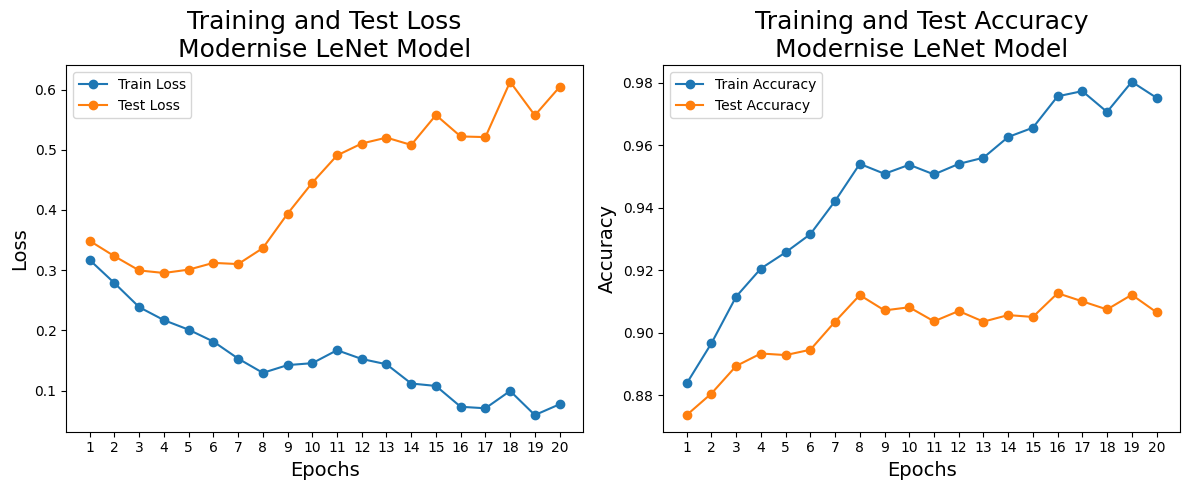

In [ ]:
# Use matplotlib to plot the train and test loss, and the train and test accuracy

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_lenet_modern, label='Train Loss', marker='o')
plt.plot(epochs, test_loss_lenet_modern, label='Test Loss', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Loss\nModernise LeNet Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_lenet_modern, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracy_lenet_modern, label='Test Accuracy', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Accuracy\nModernise LeNet Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

### <font color='red'>Your text here.</font>
<font color='red'>Enter your text descriptions in the cell below:</font>

**LeNet Model:**

During the 20 epochs, the training loss decreases from about 0.415 to 0.205, while the test loss decreases from approximately 0.441 to 0.540. Although there are some fluctuations in the loss values, the model is still learning and improving overall.


During the 20 epochs, the accuracy of the model has improved significantly. The training accuracy has increased from around 0.843 to 0.933, while the test accuracy has increased from approximately 0.835 to 0.8886. The increasing trend in both training and testing accuracies indicates that the model is learning and improving over time.

**Modernise LeNet Model:**

The provided data shows a noticeable improvement in the performance of the Modernise LeNet model compared to its original version. Specifically, the training loss decreases from 0.316 to 0.077 over 20 epochs, while the test loss decreases from 0.348 to 0.604 over the same period. It is worth noting that the Modernise LeNet model exhibits a faster and more consistent decrease in both training and test loss, indicating its superior performance.


During the 20 epochs, the training accuracy improved from around 0.8838 to 0.97525. Similarly, the test accuracy increased from approximately 0.8737 to 0.9066. Both training and test accuracies displayed a consistent increasing trend, and the final accuracies surpassed those of the original LeNet model.

**Comparison:**

The Modernise LeNet model has achieved lower final training and test losses. Moreover, it seems to converge more quickly, which indicates improved optimization. Although both models show some fluctuations in the loss, the Modernise LeNet model has smoother convergence. To sum up, the Modernise LeNet model has shown significant improvements in terms of convergence speed and final loss values, as compared to the original LeNet model.

The updated LeNet model achieves higher training and test accuracies compared to the original one. Additionally, the Modernise LeNet model shows a more consistent improvement in accuracy throughout all the epochs. Although both models exhibit some fluctuations in accuracy, the Modernise LeNet model has a smoother and more consistent increase over time. To sum up, the Modernise LeNet model has better final accuracy values and shows consistent accuracy improvement compared to the original model.

### Plotting LeNet Model and Modernise LeNet Model

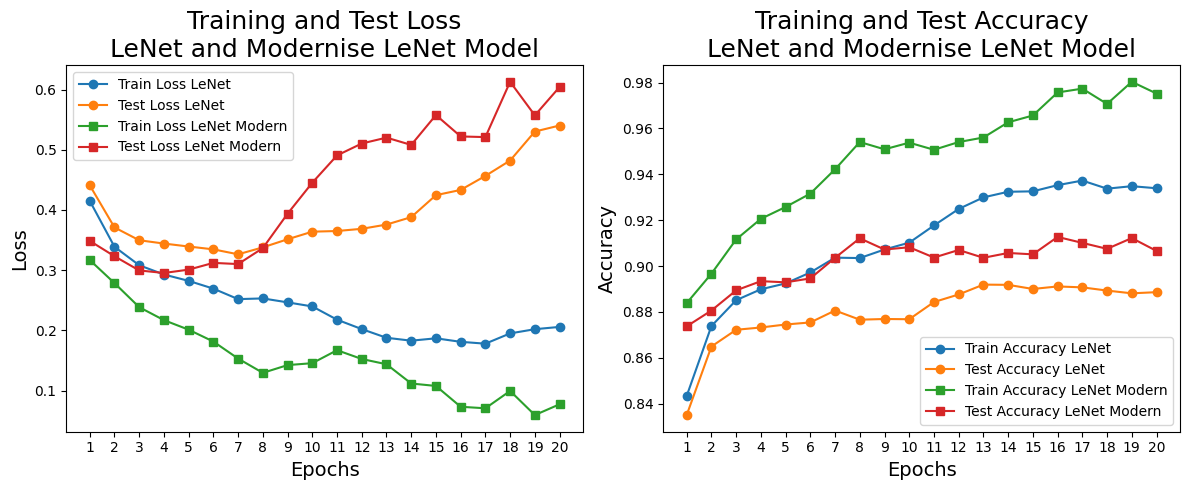

In [ ]:
# Plotting the loss LeNet Model and Modernise LeNet Model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_lenet, label='Train Loss LeNet', marker='o')
plt.plot(epochs, test_loss_lenet, label='Test Loss LeNet', marker='o')
plt.plot(epochs, train_loss_lenet_modern, label='Train Loss LeNet Modern', marker='s')
plt.plot(epochs, test_loss_lenet_modern, label='Test Loss LeNet Modern', marker='s')
plt.xticks(epochs)
plt.title('Training and Test Loss\nLeNet and Modernise LeNet Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy LeNet Model and Modernise LeNet Model
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_lenet, label='Train Accuracy LeNet', marker='o')
plt.plot(epochs, test_accuracy_lenet, label='Test Accuracy LeNet', marker='o')
plt.plot(epochs, train_accuracy_lenet_modern, label='Train Accuracy LeNet Modern', marker='s')
plt.plot(epochs, test_accuracy_lenet_modern, label='Test Accuracy LeNet Modern', marker='s')
plt.xticks(epochs)
plt.title('Training and Test Accuracy\nLeNet and Modernise LeNet Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

---
# 4. Build your own CNN model
---

Build your own classifier model - see can you break 90% accuracy. You can use LeNet as a basis if you like.

With some networks I built, I could get 93 to 94% test accuracy.

Some hints:
 * not every convolutional layer needs a pooling layer afterwards
 * Consider adding more layers (maybe more 3x3 layers is better than 1 5x5 layer?)
 * But don't just bung loads of layers in there - you will end up overfitting badly
 * Use a [batchnorm](https://towardsdatascience.com/batch-norm-explained-visually-how-it-works-and-why-neural-networks-need-it-b18919692739) after each convolutional layer. You get decent performance gains without adding many parameters
 * Don't be afraid to get to a million or two parameters
 * Have a look on Google to see what others are doing (you're going to do this anyway, right?). Don't just copy them, though, try to understand.

Explain what you did that improved things for the classification and why they improved things.

### <font color='red'>Your code here.</font>
<font color='red'>Enter your code in the cell(s) below:</font>

In [ ]:
# Define my custom architecture model
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.batch_norm1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.batch_norm3 = nn.BatchNorm2d(128)
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        # Convolutional layers with ReLU activation, batch normalization, and max pooling
        x = nn.functional.relu(self.batch_norm1(self.conv1(x)))
        x = nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        x = nn.functional.relu(self.batch_norm2(self.conv2(x)))
        x = nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        x = nn.functional.relu(self.batch_norm3(self.conv3(x)))
        x = nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        #print(x.size())
        # Flatten the output for the fully connected layers
        x = x.view(-1, 128 * 3 * 3)
        # Fully connected layers with ReLU activation
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        # Output layer
        x = self.fc3(x)
        return x

In [ ]:
# define model instance
model_myCNN = myCNN()

# "send" objects to the GPU
model_myCNN.to(device)

# show model summary
summary(model_myCNN, (1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 28, 28]          320
├─BatchNorm2d: 1-2                       [-1, 32, 28, 28]          64
├─Conv2d: 1-3                            [-1, 64, 14, 14]          18,496
├─BatchNorm2d: 1-4                       [-1, 64, 14, 14]          128
├─Conv2d: 1-5                            [-1, 128, 7, 7]           73,856
├─BatchNorm2d: 1-6                       [-1, 128, 7, 7]           256
├─Linear: 1-7                            [-1, 256]                 295,168
├─Linear: 1-8                            [-1, 128]                 32,896
├─Linear: 1-9                            [-1, 10]                  1,290
Total params: 422,474
Trainable params: 422,474
Non-trainable params: 0
Total mult-adds (M): 7.78
Input size (MB): 0.00
Forward/backward pass size (MB): 0.67
Params size (MB): 1.61
Estimated Total Size (MB): 2.29


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 28, 28]          320
├─BatchNorm2d: 1-2                       [-1, 32, 28, 28]          64
├─Conv2d: 1-3                            [-1, 64, 14, 14]          18,496
├─BatchNorm2d: 1-4                       [-1, 64, 14, 14]          128
├─Conv2d: 1-5                            [-1, 128, 7, 7]           73,856
├─BatchNorm2d: 1-6                       [-1, 128, 7, 7]           256
├─Linear: 1-7                            [-1, 256]                 295,168
├─Linear: 1-8                            [-1, 128]                 32,896
├─Linear: 1-9                            [-1, 10]                  1,290
Total params: 422,474
Trainable params: 422,474
Non-trainable params: 0
Total mult-adds (M): 7.78
Input size (MB): 0.00
Forward/backward pass size (MB): 0.67
Params size (MB): 1.61
Estimated Total Size (MB): 2.29

In [ ]:
# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_myCNN.parameters(), lr=LEARNING_RATE)   # Note, replace model with the instance name of your model

# train the model
train_loss_myCNN, train_accuracy_myCNN, test_loss_myCNN, test_accuracy_myCNN = train_loop(
    train_dataloader, test_dataloader, model_myCNN, loss_fn, optimizer, epochs=N_EPOCH)

Epoch 1:

loss: 2.285960  [   64/60000]
loss: 0.487609  [ 6464/60000]
loss: 0.289398  [12864/60000]
loss: 0.387684  [19264/60000]
loss: 0.339632  [25664/60000]
loss: 0.393314  [32064/60000]
loss: 0.265861  [38464/60000]
loss: 0.435049  [44864/60000]
loss: 0.264369  [51264/60000]
loss: 0.259422  [57664/60000]

Train Error: 
 Accuracy: 89.8%, Avg loss: 0.280557 

Test Error: 
 Accuracy: 88.6%, Avg loss: 0.321612 

Epoch 2:

loss: 0.189976  [   64/60000]
loss: 0.393523  [ 6464/60000]
loss: 0.161264  [12864/60000]
loss: 0.271107  [19264/60000]
loss: 0.384049  [25664/60000]
loss: 0.326900  [32064/60000]
loss: 0.207200  [38464/60000]
loss: 0.351792  [44864/60000]
loss: 0.202629  [51264/60000]
loss: 0.207296  [57664/60000]

Train Error: 
 Accuracy: 88.2%, Avg loss: 0.311922 

Test Error: 
 Accuracy: 86.5%, Avg loss: 0.365734 

Epoch 3:

loss: 0.206456  [   64/60000]
loss: 0.227806  [ 6464/60000]
loss: 0.161756  [12864/60000]
loss: 0.183293  [19264/60000]
loss: 0.311615  [25664/60000]
loss: 0.

In [ ]:
# print the loss in table format
print('\nmy CNN Model - Loss:')
loss_train_test = np.hstack((np.vstack(epochs), np.vstack(train_loss_myCNN), np.vstack(test_loss_myCNN)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(loss_train_test, headers, tablefmt="pretty", showindex=False))

# print the accuracy in table format
print('\nmy CNN Model - Accuracy:')
accuracy_train_test = np.hstack((np.vstack(epochs), np.vstack(train_accuracy_myCNN), np.vstack(test_accuracy_myCNN)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(accuracy_train_test, headers, tablefmt="pretty", showindex=False))


my CNN Model - Loss:
+--------+---------------------+---------------------+
| Epochs |        Train        |        Test         |
+--------+---------------------+---------------------+
|  1.0   | 0.28055700623213864 | 0.32161245139161493 |
|  2.0   | 0.3119216516439213  | 0.3657340629465261  |
|  3.0   | 0.29596287507349367 | 0.3678895466646571  |
|  4.0   | 0.25113172621440405 | 0.3409321772254956  |
|  5.0   | 0.20289664437323174 | 0.32234442993334145 |
|  6.0   | 0.16409914577201104 | 0.30080189105052096 |
|  7.0   | 0.15552402224772965 | 0.32193145934183887 |
|  8.0   | 0.1811879402461416  | 0.3880966057063668  |
|  9.0   | 0.17704516270958476 | 0.4000547515691086  |
|  10.0  | 0.14554724725944274 | 0.3982111069189895  |
|  11.0  | 0.11557285529253547 | 0.4085661814708239  |
|  12.0  | 0.13290709925508662 | 0.44319977355041323 |
|  13.0  | 0.16951357083730717 | 0.5046911809569711  |
|  14.0  | 0.08016324222222147 | 0.40811256851977223 |
|  15.0  | 0.11477673361913165 | 0.47975767

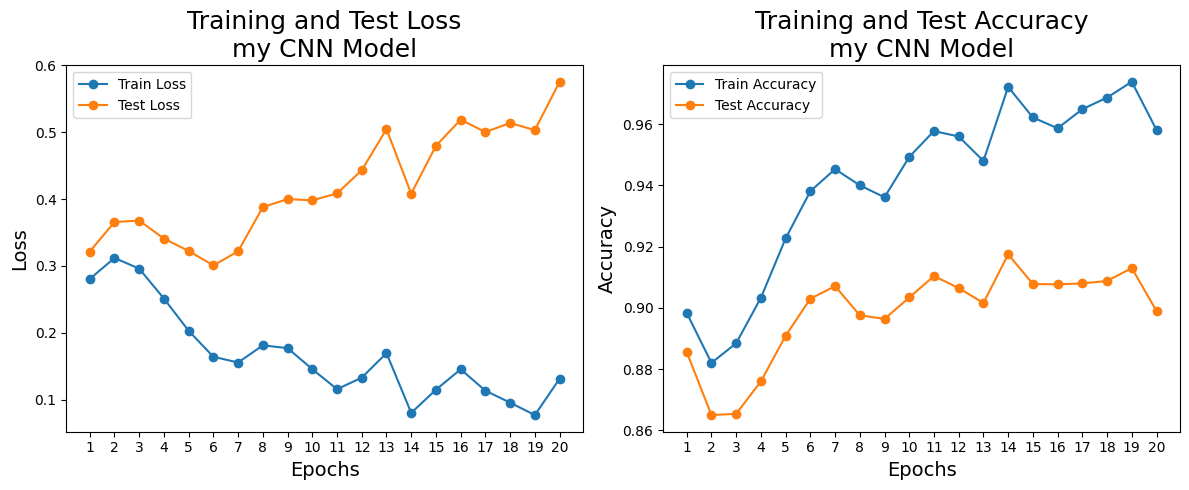

In [ ]:
# Use matplotlib to plot the train and test loss, and the train and test accuracy

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_myCNN, label='Train Loss', marker='o')
plt.plot(epochs, test_loss_myCNN, label='Test Loss', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Loss\nmy CNN Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_myCNN, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracy_myCNN, label='Test Accuracy', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Accuracy\nmy CNN Model', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

### <font color='red'>Your text here.</font>
<font color='red'>Enter your text descriptions in the cell below:</font>

Increased the number of channels in the convolutional layers from (1, 32, 64) to (32, 64, 128) to allow the model to learn more complex features.

Another convolutional layer (conv3) was added to the architecture to increase the network's capacity in capturing hierarchical features.

The number of hidden units in the fully connected layers (fc1, fc2, fc3) has been increased to allow the model to learn more complex patterns.
include batch normalization. Adding these layers can sometimes improve generalization and prevent overfitting.

Max-pooling layers with a kernel size of 2 and stride 2 were used after each convolutional layer. This helps reduce spatial dimensions and focus on essential features.

The model was trained for 20 epochs, and both the training loss and accuracy show improvement over epochs. Training for more epochs might lead to further improvements or potential overfitting.

The test set accuracy increased from 0.8714 to 0.8997 after 20 epochs, indicating better generalization.

---
# 5. Transfer Learning
---

Nobody trains large models from scratch. Rather, they use large pretrained models, that have been trained perhaps for weeks on very large datasets. Then, we can tweak the model for our needs. This allows us to use large models on small datasets and (hopefully) avoid some overfitting.

We are going to load ResNet18, we're going to cut the head off it - in this case, we will replace the very last layer. ResNet18 was trained for 1000 classes, we only have 10.

Do the following:
1. From `torchvision.models`, load [`ResNet18`](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html), and use random weights (`weights=None`). Replace the full-connected layer at the end with your own fully connect layer. Train and plot the loss and accuracy.
1. Repeat step 1, but use the default paramaters, and retrain. In this case, the default parameters.
1. Freeze all but the last layer of your adapted ResNet model, and retrain.
1. Provide some commentary on the three approaches. Particularly, what's the difference between all three approaches we outlined here?

For the freezing of layers, the following article is useful:
https://jimmy-shen.medium.com/pytorch-freeze-part-of-the-layers-4554105e03a6

In step 3 above, we may see that the network doesn't necessarily perform as well as previous networks, in terms of test accuracy. Probably we should unfreeze more of the later layers to allow better fine-tuning of the network to our problem. And there are more complicated and powerful finetuning strategies out there. But you should see that overfitting is, more or less, solved. This is because we are only training a much smaller number of parameters, and freezing all of the convolution layers in the ResNet.


In [ ]:
# We need to recreate the dataloaders, because ResNet expects a three channel
# RGB input, whereas FashionMNIST only has 1 channel (greyscale). Use
# `transforms.Grayscale(3)` to replicated the grayscale image into the three
# channels.

# Download training data from open datasets.
training_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.Resize((28,28)),
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(mean = 0.2859, std = 0.3530),
    ])
)

# Download test data from open datasets.
test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.Compose([
        transforms.Resize((28,28)),
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(mean = 0.2859, std = 0.3530),
    ])
)

batch_size = 64
# Recreate the data loaders.
train_dataloader = torch.utils.data.DataLoader(training_data, batch_size=batch_size)
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### <font color='red'>Your code here.</font>
<font color='red'>Enter your code in the cell(s) below:</font>

1. From torchvision.models, load ResNet18, and use random weights (weights=None). Replace the full-connected layer at the end with your own fully connect layer. Train and plot the loss and accuracy.

In [ ]:
# define model instance
model_resnet18_custom = torchvision.models.resnet18(weights=None)

# modify the fully connected layer with 10 classes output
feature_number = model_resnet18_custom.fc.in_features
model_resnet18_custom.fc = nn.Linear(feature_number, 10)
print(model_resnet18_custom.fc)

# "send" objects to the GPU
model_resnet18_custom.to(device)

# show model summary
summary(model_resnet18_custom, input_size=(1, 28, 28))

Linear(in_features=512, out_features=10, bias=True)
Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
|    └─BasicBlock: 2-1                   --
|    |    └─Conv2d: 3-1                  36,864
|    |    └─BatchNorm2d: 3-2             128
|    |    └─ReLU: 3-3                    --
|    |    └─Conv2d: 3-4                  36,864
|    |    └─BatchNorm2d: 3-5             128
|    └─BasicBlock: 2-2                   --
|    |    └─Conv2d: 3-6                  36,864
|    |    └─BatchNorm2d: 3-7             128
|    |    └─ReLU: 3-8                    --
|    |    └─Conv2d: 3-9                  36,864
|    |    └─BatchNorm2d: 3-10            128
├─Sequential: 1-6                        --
|    └─BasicBlock: 2-3                   --
|    |    └─Conv2d: 3-11               

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
|    └─BasicBlock: 2-1                   --
|    |    └─Conv2d: 3-1                  36,864
|    |    └─BatchNorm2d: 3-2             128
|    |    └─ReLU: 3-3                    --
|    |    └─Conv2d: 3-4                  36,864
|    |    └─BatchNorm2d: 3-5             128
|    └─BasicBlock: 2-2                   --
|    |    └─Conv2d: 3-6                  36,864
|    |    └─BatchNorm2d: 3-7             128
|    |    └─ReLU: 3-8                    --
|    |    └─Conv2d: 3-9                  36,864
|    |    └─BatchNorm2d: 3-10            128
├─Sequential: 1-6                        --
|    └─BasicBlock: 2-3                   --
|    |    └─Conv2d: 3-11                 73,728
|    |    └─BatchNorm2d: 3-12            25

In [ ]:
# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet18_custom.parameters(), lr=LEARNING_RATE) # Note, replace model with the instance name of your model

# train the model
train_loss_resnet18_custom, train_accuracy_resnet18_custom, test_loss_resnet18_custom, test_accuracy_resnet18_custom = train_loop(
    train_dataloader, test_dataloader, model_resnet18_custom, loss_fn, optimizer, epochs=N_EPOCH)

Epoch 1:

loss: 2.611698  [   64/60000]
loss: 0.524202  [ 6464/60000]
loss: 0.345381  [12864/60000]
loss: 0.477249  [19264/60000]
loss: 0.472984  [25664/60000]
loss: 0.398541  [32064/60000]
loss: 0.365057  [38464/60000]
loss: 0.492249  [44864/60000]
loss: 0.392729  [51264/60000]
loss: 0.410169  [57664/60000]

Train Error: 
 Accuracy: 85.1%, Avg loss: 0.395143 

Test Error: 
 Accuracy: 83.4%, Avg loss: 0.439441 

Epoch 2:

loss: 0.286501  [   64/60000]
loss: 0.281048  [ 6464/60000]
loss: 0.276104  [12864/60000]
loss: 0.274737  [19264/60000]
loss: 0.369850  [25664/60000]
loss: 0.354238  [32064/60000]
loss: 0.233392  [38464/60000]
loss: 0.380609  [44864/60000]
loss: 0.288377  [51264/60000]
loss: 0.294907  [57664/60000]

Train Error: 
 Accuracy: 86.2%, Avg loss: 0.363407 

Test Error: 
 Accuracy: 84.4%, Avg loss: 0.422014 

Epoch 3:

loss: 0.201269  [   64/60000]
loss: 0.223147  [ 6464/60000]
loss: 0.195982  [12864/60000]
loss: 0.253314  [19264/60000]
loss: 0.208117  [25664/60000]
loss: 0.

In [ ]:
# print the loss in table format
print('\nresnet18 Model (custom) - Loss:')
loss_train_test = np.hstack((np.vstack(epochs), np.vstack(train_loss_resnet18_custom), np.vstack(test_loss_resnet18_custom)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(loss_train_test, headers, tablefmt="pretty", showindex=False))

# print the accuracy in table format
print('\nresnet18 Model (custom) - Accuracy:')
accuracy_train_test = np.hstack((np.vstack(epochs), np.vstack(train_accuracy_resnet18_custom), np.vstack(test_accuracy_resnet18_custom)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(accuracy_train_test, headers, tablefmt="pretty", showindex=False))


resnet18 Model (custom) - Loss:
+--------+---------------------+---------------------+
| Epochs |        Train        |        Test         |
+--------+---------------------+---------------------+
|  1.0   | 0.3951427060673867  | 0.4394411133353118  |
|  2.0   | 0.36340697670478556 | 0.4220137389222528  |
|  3.0   |  0.300743895656328  | 0.36095545958181857 |
|  4.0   | 0.30367047303934086 | 0.38210045688661043 |
|  5.0   | 0.2235365865676642  | 0.31245534800609964 |
|  6.0   | 0.21950163175143414 | 0.3213803546538778  |
|  7.0   | 0.23497254429246062 | 0.3650565588740027  |
|  8.0   | 0.19740615554376326 | 0.3423261870956345  |
|  9.0   | 0.16702924426923046 | 0.32498084193771815 |
|  10.0  | 0.1551425986583712  | 0.3378124131233829  |
|  11.0  | 0.14349748709225166 | 0.3634020917497243  |
|  12.0  | 0.1292290579396556  |   0.3421657229922   |
|  13.0  | 0.11665834564351237 |  0.377617292485799  |
|  14.0  | 0.11368236033521942 |  0.361189494680637  |
|  15.0  | 0.12223807118856894 |

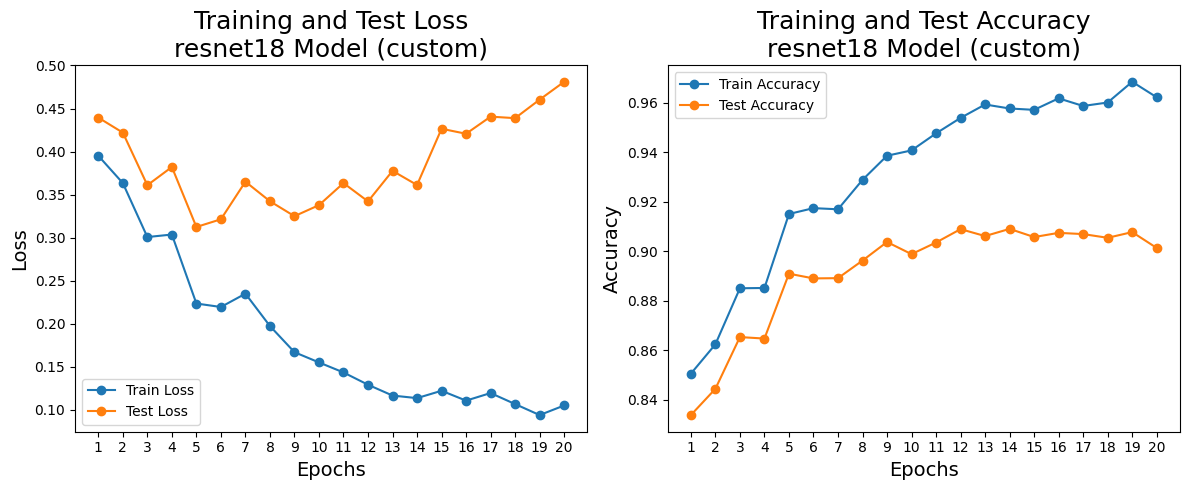

In [ ]:
# Use matplotlib to plot the train and test loss, and the train and test accuracy

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_resnet18_custom, label='Train Loss', marker='o')
plt.plot(epochs, test_loss_resnet18_custom, label='Test Loss', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Loss\nresnet18 Model (custom)', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_resnet18_custom, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracy_resnet18_custom, label='Test Accuracy', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Accuracy\nresnet18 Model (custom)', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

2. Repeat step 1, but use the default paramaters, and retrain. In this case, the default parameters.

In [ ]:
# define model instance
model_resnet18_default = torchvision.models.resnet18(weights=None)

print(model_resnet18_default.fc)

# "send" objects to the GPU
model_resnet18_default.to(device)

# show model summary
summary(model_resnet18_default, input_size=(1,28,28))

Linear(in_features=512, out_features=1000, bias=True)
Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
|    └─BasicBlock: 2-1                   --
|    |    └─Conv2d: 3-1                  36,864
|    |    └─BatchNorm2d: 3-2             128
|    |    └─ReLU: 3-3                    --
|    |    └─Conv2d: 3-4                  36,864
|    |    └─BatchNorm2d: 3-5             128
|    └─BasicBlock: 2-2                   --
|    |    └─Conv2d: 3-6                  36,864
|    |    └─BatchNorm2d: 3-7             128
|    |    └─ReLU: 3-8                    --
|    |    └─Conv2d: 3-9                  36,864
|    |    └─BatchNorm2d: 3-10            128
├─Sequential: 1-6                        --
|    └─BasicBlock: 2-3                   --
|    |    └─Conv2d: 3-11             

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
|    └─BasicBlock: 2-1                   --
|    |    └─Conv2d: 3-1                  36,864
|    |    └─BatchNorm2d: 3-2             128
|    |    └─ReLU: 3-3                    --
|    |    └─Conv2d: 3-4                  36,864
|    |    └─BatchNorm2d: 3-5             128
|    └─BasicBlock: 2-2                   --
|    |    └─Conv2d: 3-6                  36,864
|    |    └─BatchNorm2d: 3-7             128
|    |    └─ReLU: 3-8                    --
|    |    └─Conv2d: 3-9                  36,864
|    |    └─BatchNorm2d: 3-10            128
├─Sequential: 1-6                        --
|    └─BasicBlock: 2-3                   --
|    |    └─Conv2d: 3-11                 73,728
|    |    └─BatchNorm2d: 3-12            25

In [ ]:
# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet18_default.parameters(), lr=LEARNING_RATE) # Note, replace model with the instance name of your model

# train the model
train_loss_resnet18_default, train_accuracy_resnet18_default, test_loss_resnet18_default, test_accuracy_resnet18_default = train_loop(
    train_dataloader, test_dataloader, model_resnet18_default, loss_fn, optimizer, epochs=N_EPOCH)

Epoch 1:

loss: 7.323053  [   64/60000]
loss: 0.530412  [ 6464/60000]
loss: 0.308264  [12864/60000]
loss: 0.493914  [19264/60000]
loss: 0.536059  [25664/60000]
loss: 0.488781  [32064/60000]
loss: 0.367930  [38464/60000]
loss: 0.528213  [44864/60000]
loss: 0.352828  [51264/60000]
loss: 0.328619  [57664/60000]

Train Error: 
 Accuracy: 84.1%, Avg loss: 0.409857 

Test Error: 
 Accuracy: 82.7%, Avg loss: 0.453578 

Epoch 2:

loss: 0.296937  [   64/60000]
loss: 0.314483  [ 6464/60000]
loss: 0.261276  [12864/60000]
loss: 0.309390  [19264/60000]
loss: 0.286970  [25664/60000]
loss: 0.376018  [32064/60000]
loss: 0.251767  [38464/60000]
loss: 0.401613  [44864/60000]
loss: 0.303474  [51264/60000]
loss: 0.270604  [57664/60000]

Train Error: 
 Accuracy: 87.6%, Avg loss: 0.325758 

Test Error: 
 Accuracy: 85.9%, Avg loss: 0.375487 

Epoch 3:

loss: 0.219874  [   64/60000]
loss: 0.225964  [ 6464/60000]
loss: 0.223570  [12864/60000]
loss: 0.251553  [19264/60000]
loss: 0.265235  [25664/60000]
loss: 0.

In [ ]:
# print the loss in table format
print('\nresnet18 Model (default) - Loss:')
loss_train_test = np.hstack((np.vstack(epochs), np.vstack(train_loss_resnet18_default), np.vstack(test_loss_resnet18_default)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(loss_train_test, headers, tablefmt="pretty", showindex=False))

# print the accuracy in table format
print('\nresnet18 Model (default) - Accuracy:')
accuracy_train_test = np.hstack((np.vstack(epochs), np.vstack(train_accuracy_resnet18_default), np.vstack(test_accuracy_resnet18_default)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(accuracy_train_test, headers, tablefmt="pretty", showindex=False))


resnet18 Model (default) - Loss:
+--------+---------------------+---------------------+
| Epochs |        Train        |        Test         |
+--------+---------------------+---------------------+
|  1.0   | 0.40985662288376007 | 0.45357806866715666 |
|  2.0   | 0.32575827833813137 | 0.37548666580277645 |
|  3.0   | 0.30150090671106694 | 0.36121275522716484 |
|  4.0   | 0.25876795400434466 | 0.3321951542785213  |
|  5.0   | 0.21040092475775843 | 0.29643432122127267 |
|  6.0   | 0.21230635264598485 |  0.311476764358153  |
|  7.0   | 0.2070846457038321  | 0.3222317707956217  |
|  8.0   | 0.18969038073251496 | 0.32301633653177575 |
|  9.0   | 0.16142697398588537 | 0.3236648718690037  |
|  10.0  | 0.1646400321958098  | 0.3418015949902641  |
|  11.0  |  0.145210198254815  |  0.337445927700799  |
|  12.0  | 0.1274839042108069  | 0.34966977991780657 |
|  13.0  | 0.1325218768567959  | 0.3330342239540094  |
|  14.0  | 0.12298289138644036 | 0.3765872120619959  |
|  15.0  | 0.13410889132788328 

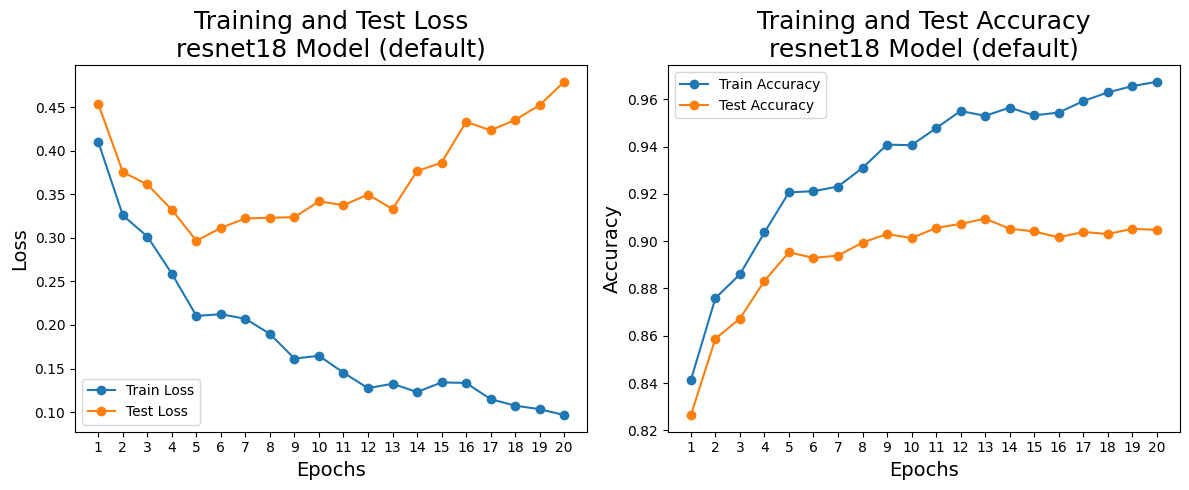

In [ ]:
# Use matplotlib to plot the train and test loss, and the train and test accuracy

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_resnet18_default, label='Train Loss', marker='o')
plt.plot(epochs, test_loss_resnet18_default, label='Test Loss', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Loss\nresnet18 Model (default)', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_resnet18_default, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracy_resnet18_default, label='Test Accuracy', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Accuracy\nresnet18 Model (default)', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

3. Freeze all but the last layer of your adapted ResNet model, and retrain.

In [ ]:
# define model instance
model_resnet18_freeze = torchvision.models.resnet18(weights=None)

# modify the fully connected layer with 10 classes output
feature_number = model_resnet18_freeze.fc.in_features
model_resnet18_freeze.fc = nn.Linear(feature_number, 10)
print(model_resnet18_freeze.fc)

# Freeze all but the last layer
for name, para in model_resnet18_freeze.named_parameters():
    if not name.startswith('fc'):
        para.requires_grad = False
    print(f'\n{"-"*30}')
    print(f'name: {name}')
    print('values: ')
    print(f'para.requires_grad: {para.requires_grad}')
    #print(para)

# "send" objects to the GPU
model_resnet18_freeze.to(device)

# show model summary
summary(model_resnet18_freeze, input_size=(1, 28, 28))

Linear(in_features=512, out_features=10, bias=True)

------------------------------
name: conv1.weight
values: 
para.requires_grad: False

------------------------------
name: bn1.weight
values: 
para.requires_grad: False

------------------------------
name: bn1.bias
values: 
para.requires_grad: False

------------------------------
name: layer1.0.conv1.weight
values: 
para.requires_grad: False

------------------------------
name: layer1.0.bn1.weight
values: 
para.requires_grad: False

------------------------------
name: layer1.0.bn1.bias
values: 
para.requires_grad: False

------------------------------
name: layer1.0.conv2.weight
values: 
para.requires_grad: False

------------------------------
name: layer1.0.bn2.weight
values: 
para.requires_grad: False

------------------------------
name: layer1.0.bn2.bias
values: 
para.requires_grad: False

------------------------------
name: layer1.1.conv1.weight
values: 
para.requires_grad: False

------------------------------
name: layer

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            (9,408)
├─BatchNorm2d: 1-2                       (128)
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
|    └─BasicBlock: 2-1                   --
|    |    └─Conv2d: 3-1                  (36,864)
|    |    └─BatchNorm2d: 3-2             (128)
|    |    └─ReLU: 3-3                    --
|    |    └─Conv2d: 3-4                  (36,864)
|    |    └─BatchNorm2d: 3-5             (128)
|    └─BasicBlock: 2-2                   --
|    |    └─Conv2d: 3-6                  (36,864)
|    |    └─BatchNorm2d: 3-7             (128)
|    |    └─ReLU: 3-8                    --
|    |    └─Conv2d: 3-9                  (36,864)
|    |    └─BatchNorm2d: 3-10            (128)
├─Sequential: 1-6                        --
|    └─BasicBlock: 2-3                   --
|    |    └─Conv2d: 3-11                 (73,728)
|    |    └─BatchNorm

In [ ]:
# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet18_freeze.parameters(), lr=LEARNING_RATE) # Note, replace model with the instance name of your model

# train the model
train_loss_resnet18_freeze, train_accuracy_resnet18_freeze, test_loss_resnet18_freeze, test_accuracy_resnet18_freeze = train_loop(
    train_dataloader, test_dataloader, model_resnet18_freeze, loss_fn, optimizer, epochs=N_EPOCH)

Epoch 1:

loss: 2.481145  [   64/60000]
loss: 1.036159  [ 6464/60000]
loss: 0.682240  [12864/60000]
loss: 0.919440  [19264/60000]
loss: 0.902478  [25664/60000]
loss: 0.942293  [32064/60000]
loss: 0.844443  [38464/60000]
loss: 0.809944  [44864/60000]
loss: 0.750730  [51264/60000]
loss: 0.748588  [57664/60000]

Train Error: 
 Accuracy: 75.3%, Avg loss: 0.710138 

Test Error: 
 Accuracy: 73.8%, Avg loss: 0.754202 

Epoch 2:

loss: 0.675367  [   64/60000]
loss: 0.738542  [ 6464/60000]
loss: 0.523409  [12864/60000]
loss: 0.793977  [19264/60000]
loss: 0.805462  [25664/60000]
loss: 0.853600  [32064/60000]
loss: 0.777850  [38464/60000]
loss: 0.783431  [44864/60000]
loss: 0.704662  [51264/60000]
loss: 0.689984  [57664/60000]

Train Error: 
 Accuracy: 76.1%, Avg loss: 0.678389 

Test Error: 
 Accuracy: 74.4%, Avg loss: 0.733914 

Epoch 3:

loss: 0.641921  [   64/60000]
loss: 0.691221  [ 6464/60000]
loss: 0.496685  [12864/60000]
loss: 0.765490  [19264/60000]
loss: 0.777431  [25664/60000]
loss: 0.

In [ ]:
# print the loss in table format
print('\nresnet18 Model (freeze) - Loss:')
loss_train_test = np.hstack((np.vstack(epochs), np.vstack(train_loss_resnet18_freeze), np.vstack(test_loss_resnet18_freeze)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(loss_train_test, headers, tablefmt="pretty", showindex=False))

# print the accuracy in table format
print('\nresnet18 Model (freeze) - Accuracy:')
accuracy_train_test = np.hstack((np.vstack(epochs), np.vstack(train_accuracy_resnet18_freeze), np.vstack(test_accuracy_resnet18_freeze)))
headers = ['Epochs', 'Train', 'Test']
print(tabulate(accuracy_train_test, headers, tablefmt="pretty", showindex=False))


resnet18 Model (freeze) - Loss:
+--------+--------------------+--------------------+
| Epochs |       Train        |        Test        |
+--------+--------------------+--------------------+
|  1.0   | 0.7101378745870042 | 0.7542016312574885 |
|  2.0   | 0.6783894501261111 | 0.7339142061722507 |
|  3.0   | 0.6679087559869294 | 0.731046958334127  |
|  4.0   | 0.6633269278797259 | 0.731981552710199  |
|  5.0   | 0.6610078890758283 |  0.73386502512701  |
|  6.0   | 0.6597142898833065 | 0.7358703905609763 |
|  7.0   | 0.6589378993839089 | 0.7377381600012445 |
|  8.0   | 0.6584432291577874 | 0.7393980172409373 |
|  9.0   | 0.6581111191622993 | 0.7408464326980008 |
|  10.0  | 0.6578772896324901 | 0.742102602674703  |
|  11.0  | 0.6577052377434428 | 0.7431916089574243 |
|  12.0  | 0.6575733915702112 | 0.7441380534582077 |
|  13.0  | 0.6574685956750598 | 0.7449638938448232 |
|  14.0  | 0.6573825944651926 | 0.7456880280166674 |
|  15.0  | 0.6573100769634186 | 0.7463262193142228 |
|  16.0  | 0.

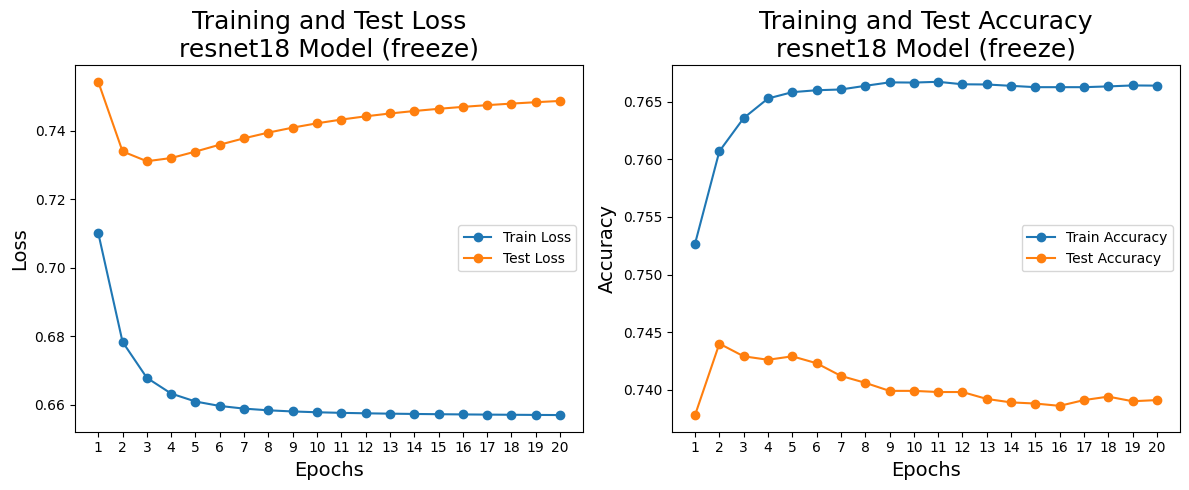

In [ ]:
# Use matplotlib to plot the train and test loss, and the train and test accuracy

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_resnet18_freeze, label='Train Loss', marker='o')
plt.plot(epochs, test_loss_resnet18_freeze, label='Test Loss', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Loss\nresnet18 Model (freeze)', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_resnet18_freeze, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracy_resnet18_freeze, label='Test Accuracy', marker='o')
plt.xticks(epochs)
plt.title('Training and Test Accuracy\nresnet18 Model (freeze)', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

### <font color='red'>Your text here.</font>
<font color='red'>Enter your text descriptions in the cell below:</font>

The differences between these three approaches:

**model_resnet18_custom:**

Create a trainable instance of ResNet-18 (model_resnet18_custom) with random weights and modify the fc layer to output 10 classes.


**model_resnet18_default:**

Create a new instance of ResNet-18 (model_resnet18_default) with random weights. This model is not modified, and the fully connected layer is the default one. The entire model is trainable, and there are no frozen layers.


**model_resnet18_freeze:**

To create the model_resnet18_freeze instance, I follow the same process as for model_resnet18_custom, but with random weights. I then modify the fully connected layer (fc) to output 10 classes instead of the default number of classes. I freeze all layers except the last fully connected layer. This means that only the parameters of the last fully connected layer are trainable, and the rest of the model is frozen.



**Summary:**


* There are three variants of the ResNet-18 model: model_resnet18_custom,model_resnet18_default, and model_resnet18_freeze.

* Model_resnet18_custom is customised for 10 classes, with a modified fully connected layer. The entire model is trainable.

* Model_resnet18_default is a standard ResNet-18 with random weights and the default fully connected layer. The entire model is trainable.

* Model_resnet18_freeze is customised for 10 classes, with a modified fully connected layer. All layers except the last fully connected layer are frozen, meaning that only the last fully connected layer is trainable.